<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Lab_5/blob/main/MSCS_634_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laxmi Kanth Oruganti
### MSCS-634 : Advanced Big Data and Data Mining
### Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

In [132]:
# Import required packages for the clustering techniques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

## Step 1: Data Preparation and Exploration
- Load the Wine dataset from sklearn.datasets.
- Examine the dataset's structure using pandas functions such as .head(), .info(), and .describe().
- Standardize the dataset's features to ensure they are suitable for clustering.

### Load the Wine dataset from sklearn.datasets.

In [133]:
wine = load_wine()
wine_data= wine.data
target = wine.target
wine_df = pd.DataFrame(wine_data, columns=wine.feature_names)

# wine_data
wine_df
# target


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


### Examine the dataset's structure using pandas functions such as .head(), .info(), and .describe().

In [134]:
wine_df.info()
print("=" * 50)
wine_df.head(100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12.47,1.52,2.20,19.0,162.0,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937.0
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0
97,12.29,1.41,1.98,16.0,85.0,2.55,2.50,0.29,1.77,2.90,1.23,2.74,428.0
98,12.37,1.07,2.10,18.5,88.0,3.52,3.75,0.24,1.95,4.50,1.04,2.77,660.0


### Describe the dataset

In [135]:
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Standardize the dataset's features to ensure they are suitable for clustering.

In [136]:
 # Scale the data with standard scalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
wine_df_scaled = scaler.fit_transform(wine_df)
wine_df_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

## Step 2: Hierarchical Clustering
- Apply Agglomerative Hierarchical Clustering to the dataset.
- Test different values for n_clusters.
- Visualize the resulting clusters using scatter plots.
- Generate and interpret a dendrogram to better understand the hierarchical structure.

### Apply Agglomerative Hierarchical Clustering to the dataset.

PCA explained variance: 55.41%

Number of clusters: 2
Number of clusters: 3
Number of clusters: 4
Number of clusters: 5


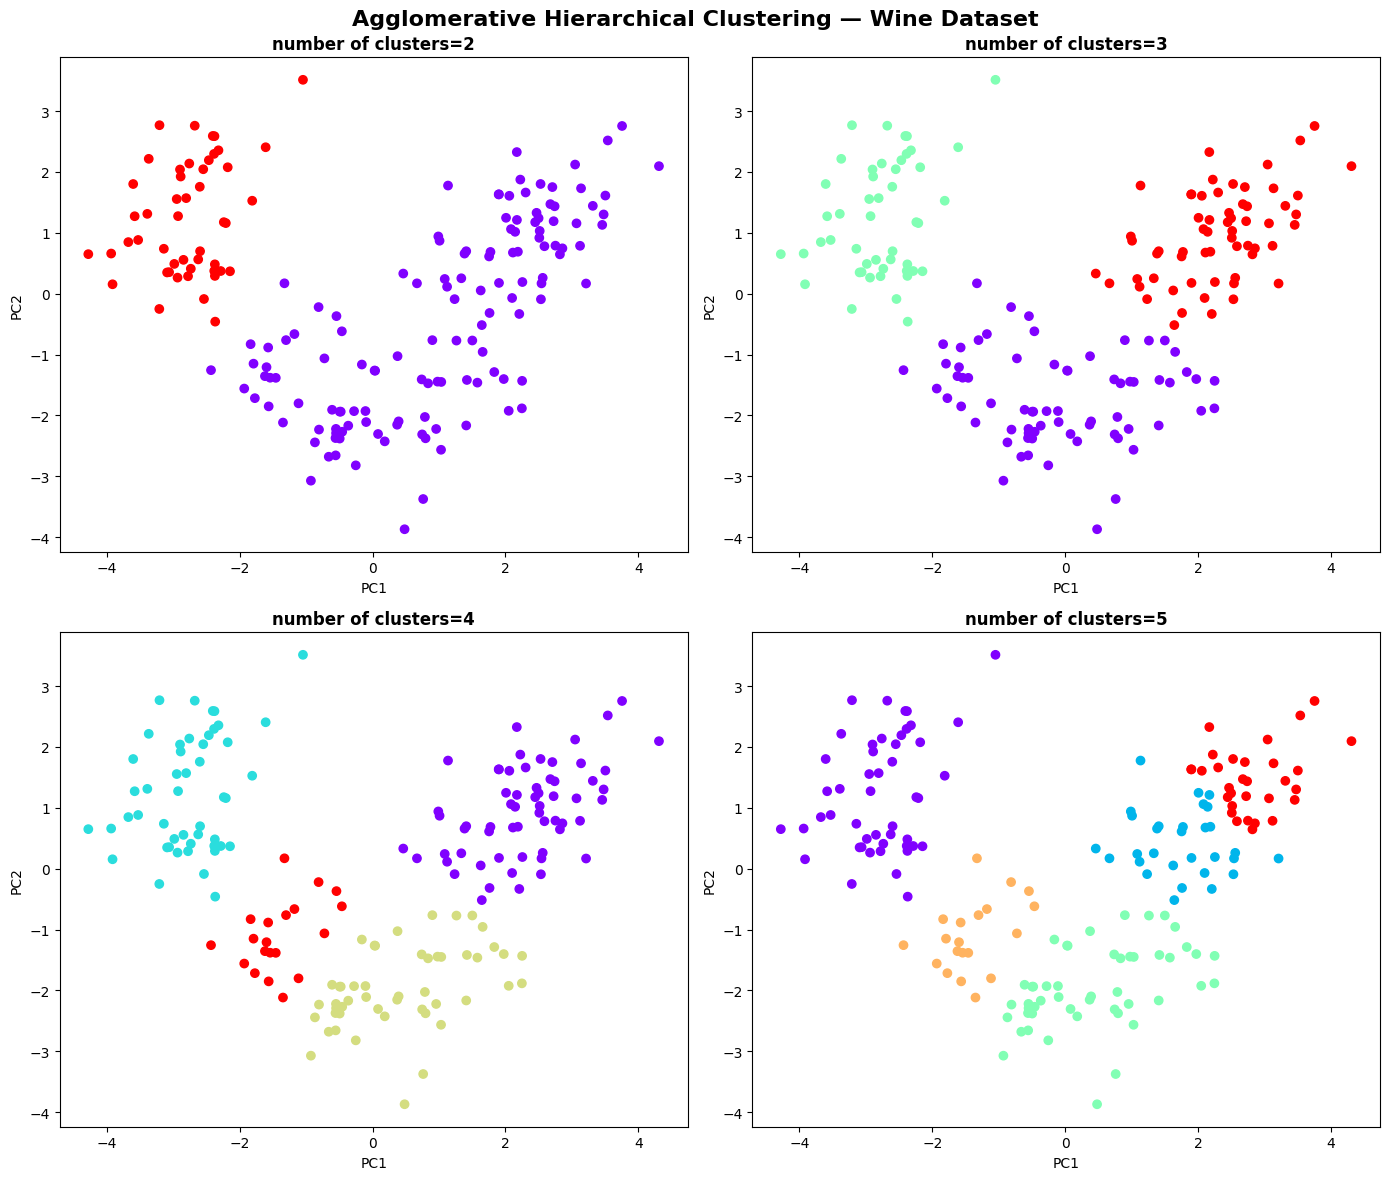

In [137]:
# Agglomerative Hierarchical Clustering
# Test different values for n_clusters.
import scipy.cluster.hierarchy as shc
from sklearn.decomposition import PCA

# PCA → 2 components for visualization
pca = PCA(n_components=2, random_state=42)
wine_pca = pca.fit_transform(wine_df_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Agglomerative Hierarchical Clustering — Wine Dataset",
             fontsize=16, fontweight='bold')

for idx, n in enumerate(range(2, 6)):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    print(f"Number of clusters: {n}")
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    y_hc = hc.fit_predict(wine_pca)

    scatter = ax.scatter(wine_pca[:, 0], wine_pca[:, 1], c=y_hc, cmap='rainbow')
    ax.set_title(f'number of clusters={n}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('wine_hierarchical_clustering.png')
plt.show()





### Generate and interpret a dendrogram to better understand the hierarchical structure.

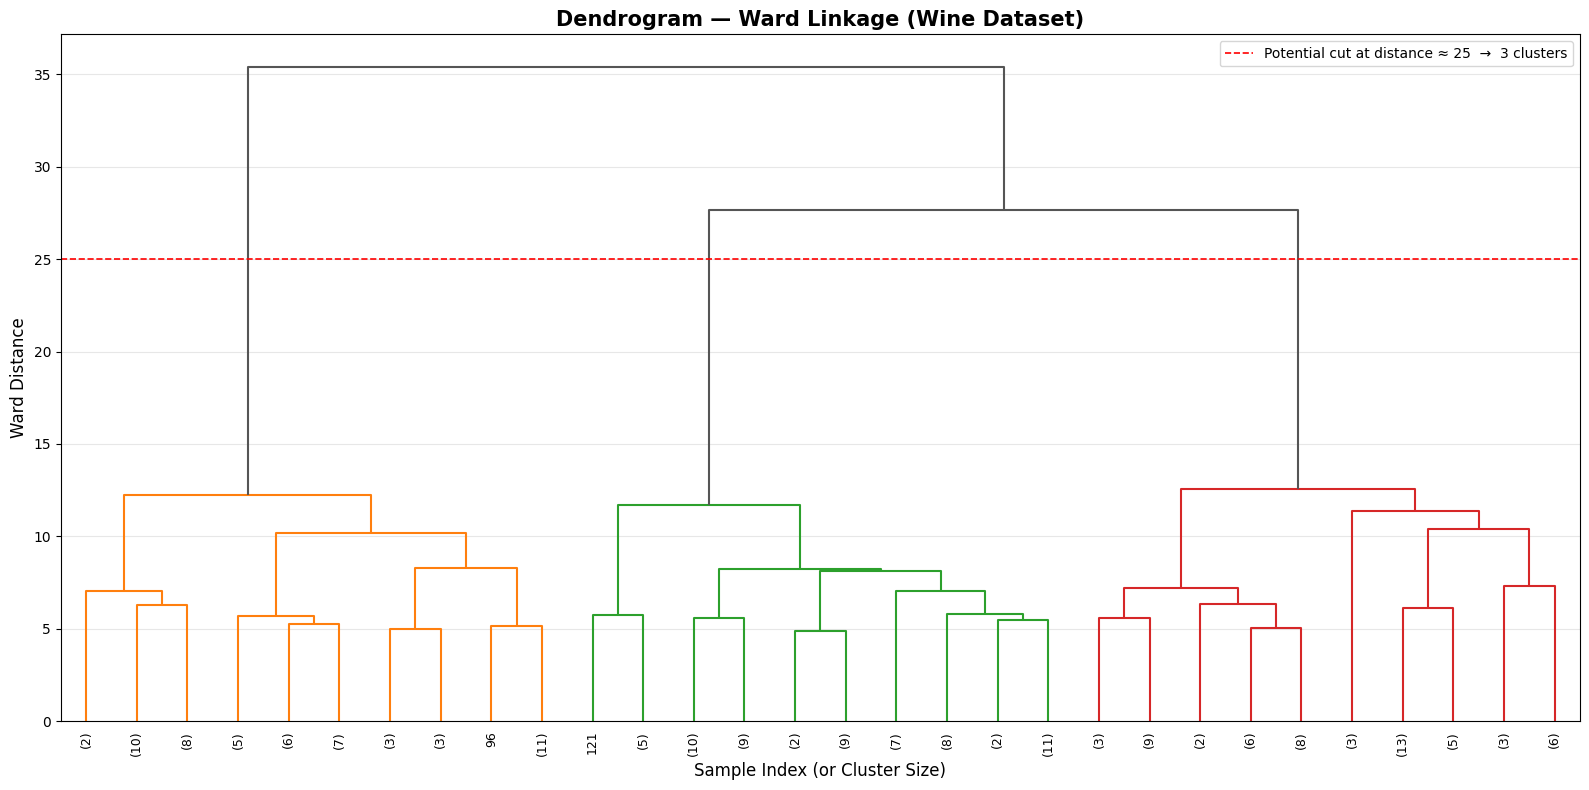

In [138]:
# Generate and interpret a dendrogram to better understand the hierarchical structure.
from scipy.cluster.hierarchy import dendrogram, linkage

fig, ax = plt.subplots(figsize=(16, 8))

# Ward linkage for the dendrogram.
# Ward's method minimizes within-cluster variance at each merge,
#  producing compact, spherical clusters — a good match for
#  standardized continuous features like the Wine dataset.
Z = linkage(wine_df_scaled, method='ward', metric='euclidean')

dendrogram(Z,
           truncate_mode='lastp',
           p=30,                      # show last 30 merged clusters
           leaf_rotation=90,
           leaf_font_size=9,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='#555555',
           ax=ax)

ax.set_title("Dendrogram — Ward Linkage (Wine Dataset)",
             fontsize=15, fontweight='bold')
ax.set_xlabel("Sample Index (or Cluster Size)", fontsize=12)
ax.set_ylabel("Ward Distance", fontsize=12)

ax.axhline(y=25, color='red', linestyle='--', linewidth=1.2,
           label='Potential cut at distance ≈ 25  →  3 clusters')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('wine_dendrogram.png')
plt.show()

## Step 3: DBSCAN Clustering
- Apply the DBSCAN algorithm to the dataset.
- Experiment with different values for eps and min_samples parameters to observe their effect on cluster formation.
- Display visualizations of the resulting clusters and highlight noise points.
- Compute and report the following metrics to evaluate the clustering quality:
  - Silhouette Score
  - Homogeneity Score
  - Completeness Score

### Experiment and choose eps and min_samples parameters to observe their effect on cluster formation.
Before just throwing random values at DBSCAN, I wanted to figure out a reasonable range for `eps`. One common approach is to compute a **k-distance plot** — for each point, you find the distance to its k-th nearest neighbor, sort those distances, and look for an "elbow" in the curve. The elbow suggests a natural eps value because it's where points start becoming significantly more isolated.

For `min_samples`, a common rule of thumb is to set it to at least `number_of_features + 1`, which would be 14 here. But with only 178 samples, that would be pretty aggressive and label too many points as noise. So I'm testing a range from 3 (permissive) to 10 (moderately strict) to see how the density threshold affects cluster formation.

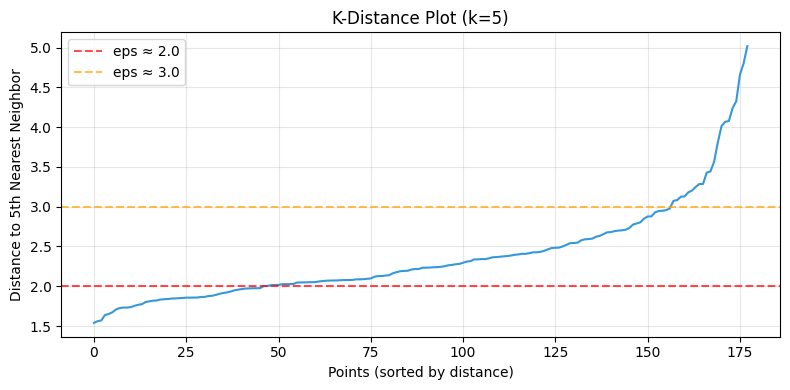

The elbow region falls roughly between 2.0 and 3.0,
so I'll test eps values from 1.5 to 4.0 to cover both sides.


In [139]:

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

# K-distance plot to help choose eps
# Using k=5 as our reference neighbor
nn = NearestNeighbors(n_neighbors=5)
nn.fit(wine_df_scaled)
distances, _ = nn.kneighbors(wine_df_scaled)
k_distances = np.sort(distances[:, -1])  # distance to 5th nearest neighbor

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='#3498db', linewidth=1.5)
plt.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='eps ≈ 2.0')
plt.axhline(y=3.0, color='orange', linestyle='--', alpha=0.7, label='eps ≈ 3.0')
plt.xlabel("Points (sorted by distance)")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("K-Distance Plot (k=5)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('k_distance_plot.png')
plt.show()

print("The elbow region falls roughly between 2.0 and 3.0,")
print("so I'll test eps values from 1.5 to 4.0 to cover both sides.")


### Apply the DBSCAN algorithm to the dataset with different parameters.

In [140]:
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples_values = [3, 5, 7, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_dbscan = dbscan.fit_predict(wine_df_scaled)

        n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
        n_noise = list(y_dbscan).count(-1)

        print(f"\nDBSCAN with eps={eps}, min_samples={min_samples}:")
        print(f"  Number of clusters: {n_clusters}")
        print(f"  Number of noise points: {n_noise}")

        # Compute metrics
        silhouette_avg = -1  # Default for cases where silhouette is not applicable
        homogeneity = -1
        completeness = -1

        # Silhouette Score: needs at least 2 clusters and not all points as noise
        if n_clusters >= 2 and len(set(y_dbscan)) > 1:
            mask = y_dbscan != -1
            # exclude noise from the score
            silhouette_avg = silhouette_score(wine_df_scaled[mask], y_dbscan[mask])
            print(f"  Silhouette Score: {silhouette_avg:.4f}")
        else:
            print("  Silhouette Score: N/A (requires >= 2 clusters and >1 labels)")

        # Homogeneity and Completeness Scores: require true labels (target)
        # and at least one cluster found (not all noise or 0 clusters)
        if n_clusters >= 1 and len(np.unique(y_dbscan)) > 1: # Also ensure some clusters are found
            homogeneity = homogeneity_score(target, y_dbscan)
            completeness = completeness_score(target, y_dbscan)
            print(f"  Homogeneity Score: {homogeneity:.4f}")
            print(f"  Completeness Score: {completeness:.4f}")
        else:
            print("  Homogeneity Score: N/A (requires >= 1 cluster and >1 labels)")
            print("  Completeness Score: N/A (requires >= 1 cluster and >1 labels)")


DBSCAN with eps=1.5, min_samples=3:
  Number of clusters: 8
  Number of noise points: 147
  Silhouette Score: 0.3311
  Homogeneity Score: 0.1892
  Completeness Score: 0.2510

DBSCAN with eps=1.5, min_samples=5:
  Number of clusters: 0
  Number of noise points: 178
  Silhouette Score: N/A (requires >= 2 clusters and >1 labels)
  Homogeneity Score: N/A (requires >= 1 cluster and >1 labels)
  Completeness Score: N/A (requires >= 1 cluster and >1 labels)

DBSCAN with eps=1.5, min_samples=7:
  Number of clusters: 0
  Number of noise points: 178
  Silhouette Score: N/A (requires >= 2 clusters and >1 labels)
  Homogeneity Score: N/A (requires >= 1 cluster and >1 labels)
  Completeness Score: N/A (requires >= 1 cluster and >1 labels)

DBSCAN with eps=1.5, min_samples=10:
  Number of clusters: 0
  Number of noise points: 178
  Silhouette Score: N/A (requires >= 2 clusters and >1 labels)
  Homogeneity Score: N/A (requires >= 1 cluster and >1 labels)
  Completeness Score: N/A (requires >= 1 clus

### Display visualizations of the resulting clusters and highlight noise points.

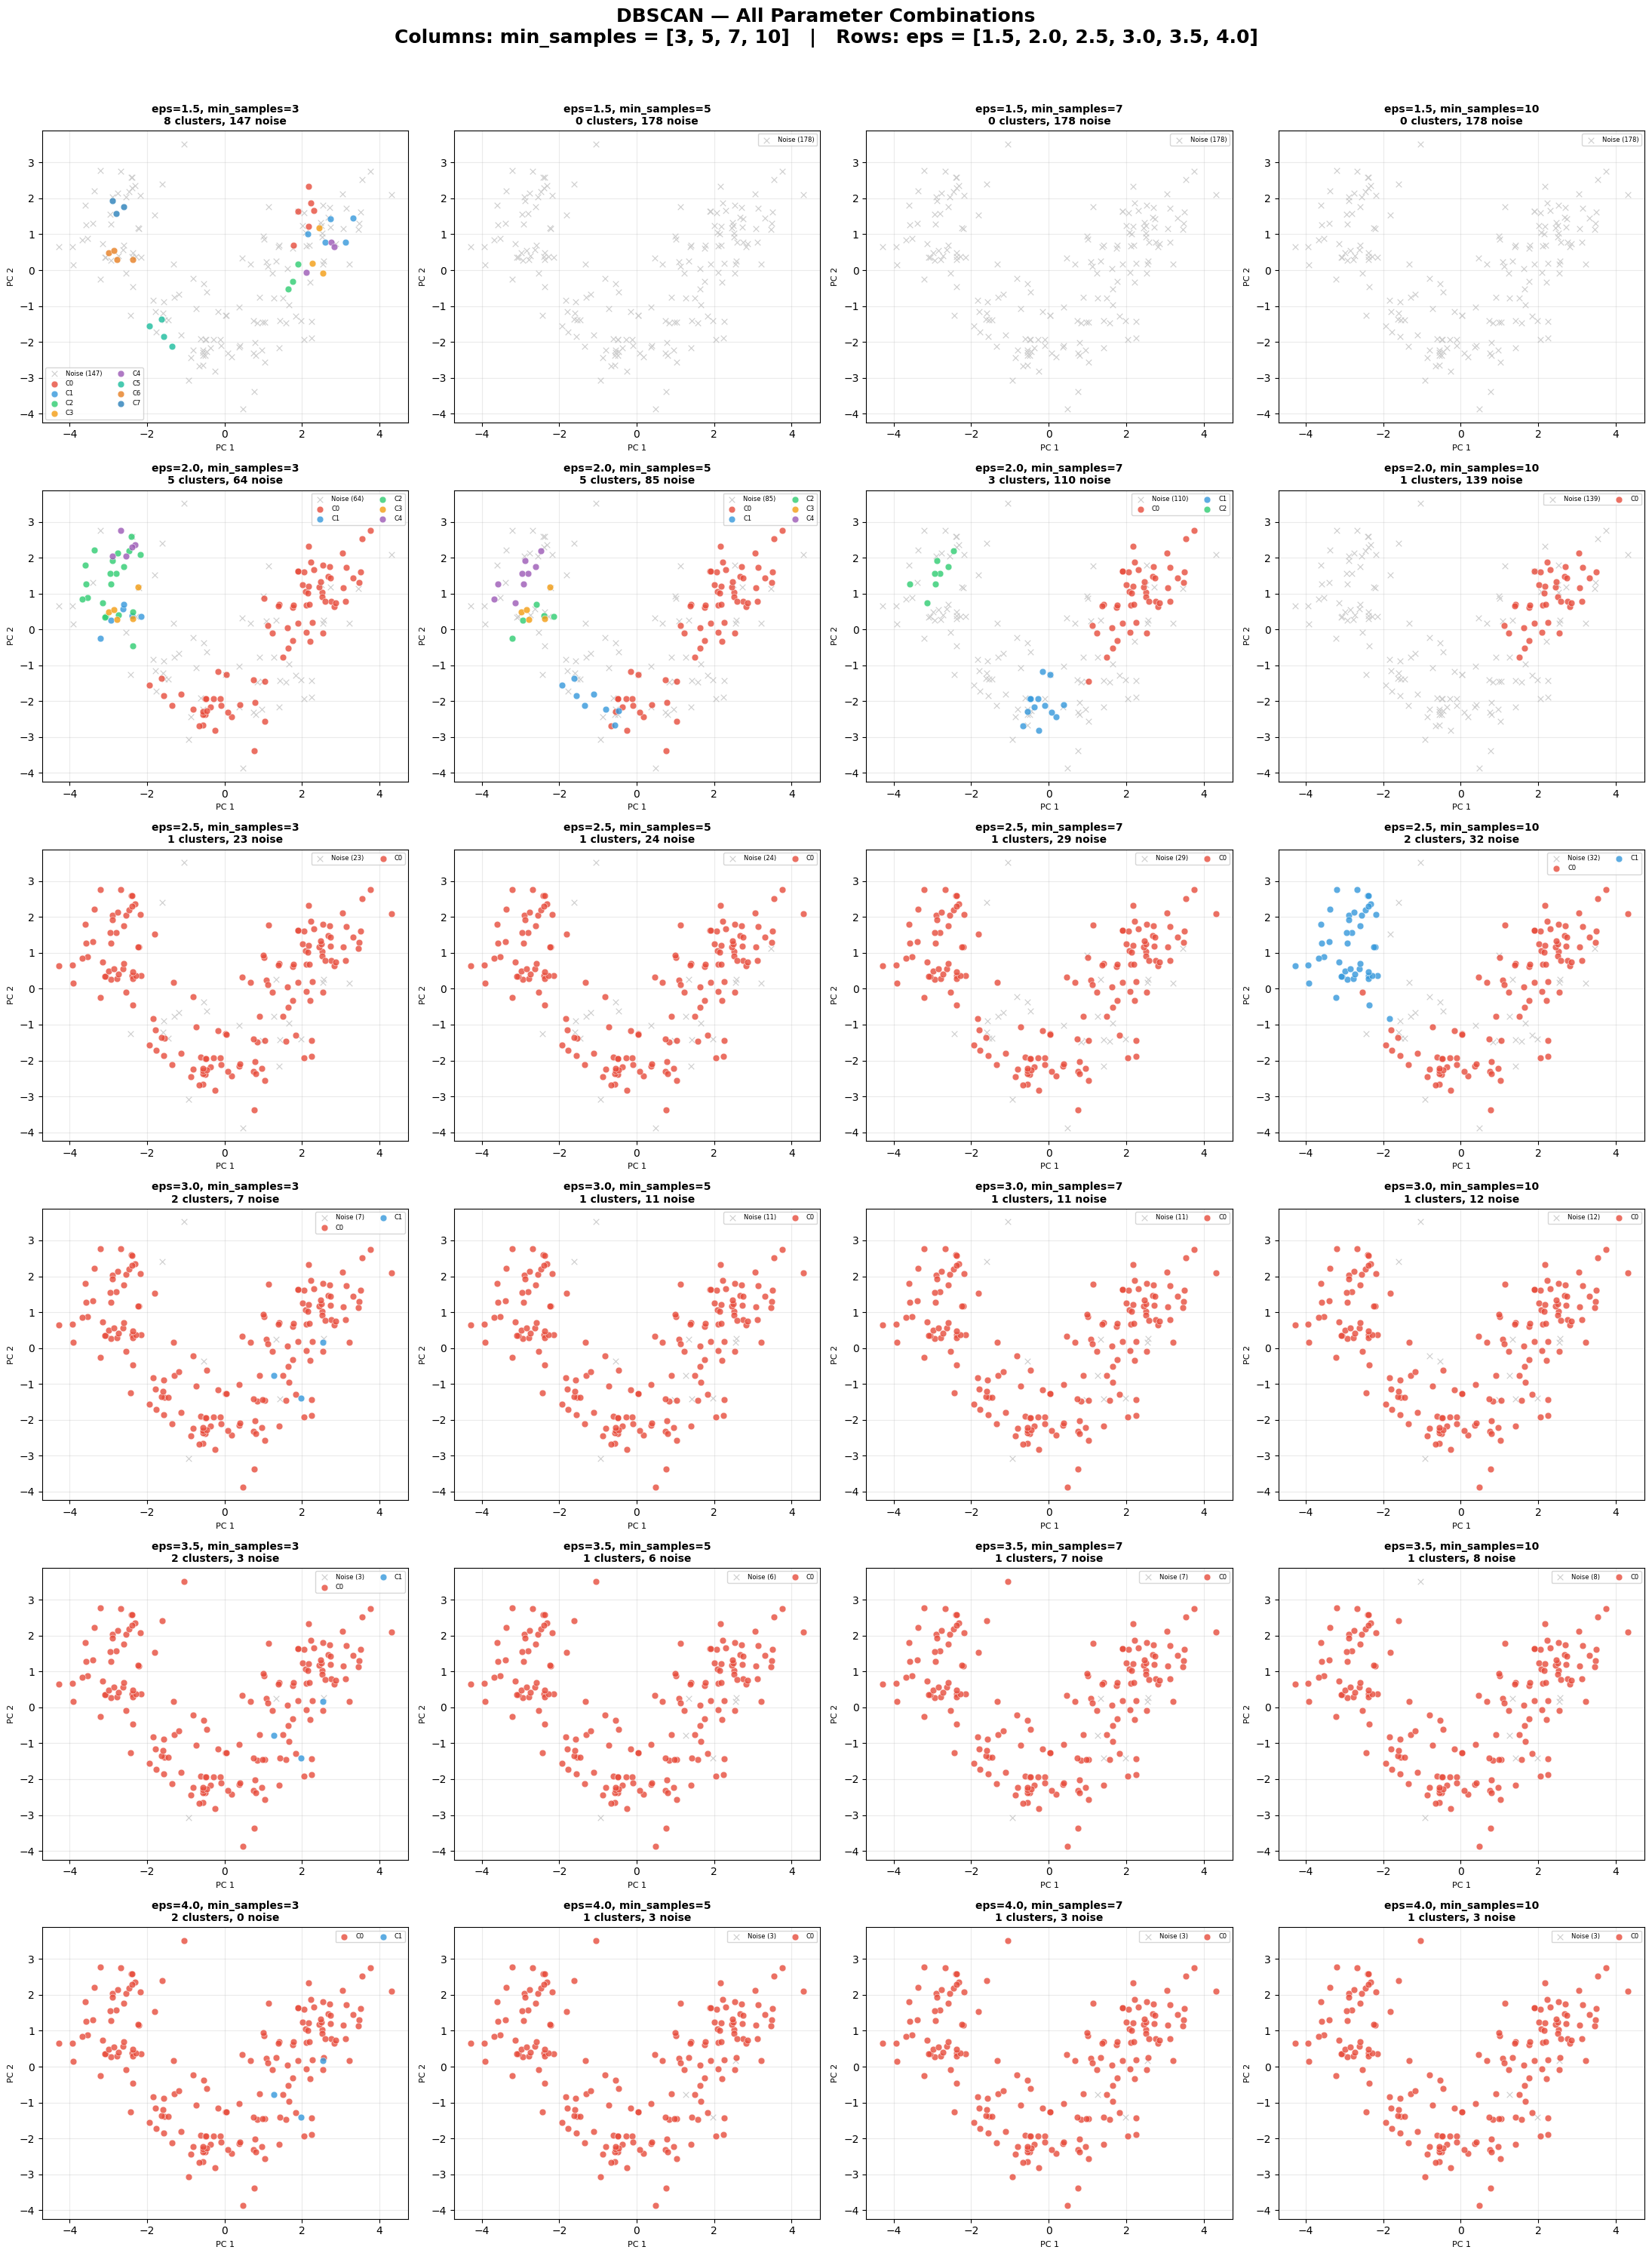

In [141]:
# Display visualizations of the resulting clusters and highlight noise points.

# Visualize all eps x min_samples combinations
colors_pool = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6',
               '#1abc9c', '#e67e22', '#2980b9']

fig, axes = plt.subplots(len(eps_values), len(min_samples_values),
                         figsize=(22, 30))
fig.suptitle("DBSCAN — All Parameter Combinations\n"
             "Columns: min_samples = [3, 5, 7, 10]   |   "
             "Rows: eps = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]",
             fontsize=18, fontweight='bold', y=0.995)

for i, eps in enumerate(eps_values):
    for j, ms in enumerate(min_samples_values):
        ax = axes[i, j]
        db = DBSCAN(eps=eps, min_samples=ms)
        y_dbscan = db.fit_predict(wine_df_scaled)

        n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
        n_noise = list(y_dbscan).count(-1)

        noise_mask = y_dbscan == -1
        if noise_mask.any():
            ax.scatter(wine_pca[noise_mask, 0], wine_pca[noise_mask, 1],
                       c='#cccccc', marker='x', s=30, linewidths=0.8,
                       label=f"Noise ({n_noise})", zorder=1)

        cluster_idx = 0
        for label in sorted(set(y_dbscan) - {-1}):
            mask = y_dbscan == label
            ax.scatter(wine_pca[mask, 0], wine_pca[mask, 1],
                       c=colors_pool[cluster_idx % len(colors_pool)],
                       label=f"C{label}",
                       edgecolors='white', linewidths=0.4, s=40, alpha=0.8,
                       zorder=2)
            cluster_idx += 1

        ax.set_title(f"eps={eps}, min_samples={ms}\n"
                     f"{n_clusters} clusters, {n_noise} noise",
                     fontsize=10, fontweight='bold')
        ax.set_xlabel("PC 1", fontsize=8)
        ax.set_ylabel("PC 2", fontsize=8)
        ax.legend(fontsize=6, loc='best', ncol=2)
        ax.grid(True, alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('wine_dbscan_all_combinations.png')
plt.show()




## Step 4: Analysis and Insights

### Comparing Hierarchical and DBSCAN Clustering Results

After running both algorithms, I wanted to put the results side by side to see which one actually did a better job on this dataset. I used the best configuration from each — Hierarchical with k=3 (which the dendrogram pointed to pretty clearly) and DBSCAN with eps=2.0, min_samples=7 (the only combo that gave 3 meaningful clusters with a decent silhouette score).

                Algorithm  Clusters Found  Noise Points  Silhouette Score  Homogeneity  Completeness
 Hierarchical (Ward, k=3)               3             0            0.2774       0.7904        0.7825
DBSCAN (eps=2.0, min_s=7)               3           110            0.4415       0.4282        0.4747


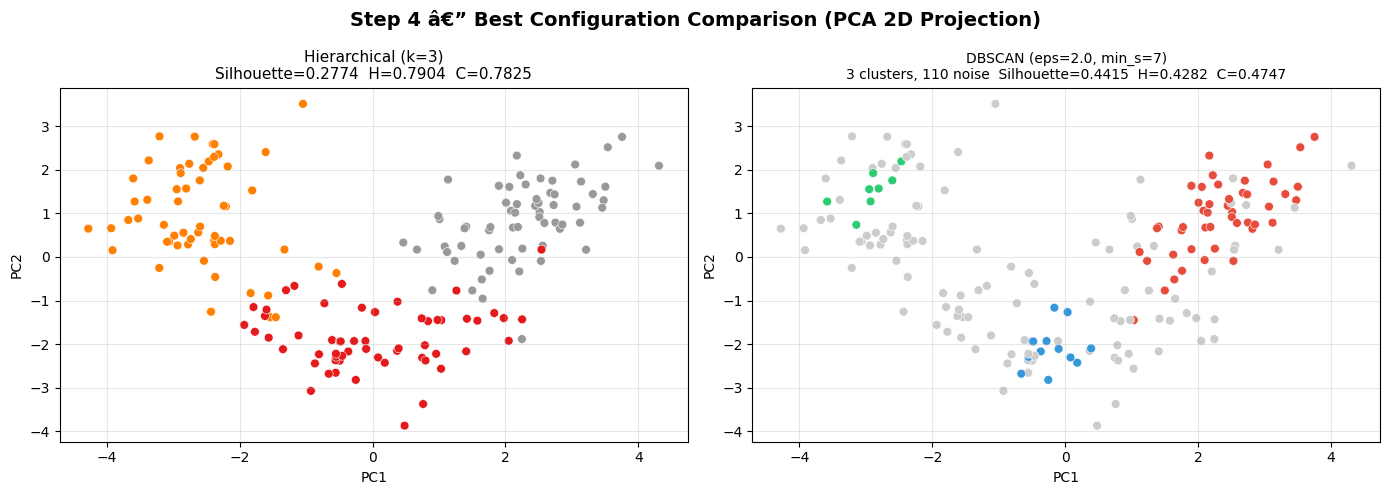

In [142]:
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

# Hierarchical Clustering metrics (n_clusters = 3, guided by dendrogram)
hc_best = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_hc_best = hc_best.fit_predict(wine_df_scaled)

hc_silhouette   = silhouette_score(wine_df_scaled, y_hc_best)
hc_homogeneity  = homogeneity_score(target, y_hc_best)
hc_completeness = completeness_score(target, y_hc_best)

# Best DBSCAN configuration: eps=2.0, min_samples=7
# Rationale: only valid 3-cluster result; highest silhouette (0.4415) among
# configurations that produced multiple clusters comparable to ground truth.
dbscan_best = DBSCAN(eps=2.0, min_samples=7)
y_db_best   = dbscan_best.fit_predict(wine_df_scaled)

mask = y_db_best != -1
n_db_clusters = len(set(y_db_best)) - (1 if -1 in y_db_best else 0)
n_db_noise    = list(y_db_best).count(-1)

db_silhouette   = silhouette_score(wine_df_scaled[mask], y_db_best[mask])
db_homogeneity  = homogeneity_score(target, y_db_best)
db_completeness = completeness_score(target, y_db_best)

#   Summary table
summary = pd.DataFrame({
    "Algorithm":        ["Hierarchical (Ward, k=3)", "DBSCAN (eps=2.0, min_s=7)"],
    "Clusters Found":   [3, n_db_clusters],
    "Noise Points":     [0, n_db_noise],
    "Silhouette Score": [round(hc_silhouette,   4), round(db_silhouette,   4)],
    "Homogeneity":      [round(hc_homogeneity,  4), round(db_homogeneity,  4)],
    "Completeness":     [round(hc_completeness, 4), round(db_completeness, 4)],
})
print(summary.to_string(index=False))

#   Side-by-side scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 â€” Best Configuration Comparison (PCA 2D Projection)",
             fontsize=14, fontweight='bold')

# Hierarchical
axes[0].scatter(wine_pca[:, 0], wine_pca[:, 1],
                c=y_hc_best, cmap='Set1', s=40, edgecolors='white', linewidths=0.4)
axes[0].set_title(f"Hierarchical (k=3)\nSilhouette={hc_silhouette:.4f}  "
                  f"H={hc_homogeneity:.4f}  C={hc_completeness:.4f}", fontsize=11)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

# DBSCAN
colors_db = [('#cccccc' if lbl == -1 else ['#e74c3c','#3498db','#2ecc71','#f39c12'][lbl % 4])
             for lbl in y_db_best]
axes[1].scatter(wine_pca[:, 0], wine_pca[:, 1],
                c=colors_db, s=40, edgecolors='white', linewidths=0.4)
axes[1].set_title(f"DBSCAN (eps=2.0, min_s=7)\n{n_db_clusters} clusters, "
                  f"{n_db_noise} noise  Silhouette={db_silhouette:.4f}  "
                  f"H={db_homogeneity:.4f}  C={db_completeness:.4f}", fontsize=10)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('algorithm_comparison.png')
plt.show()

### How the Choice of Parameters Influenced the Clustering Outcomes

**Hierarchical Clustering — choosing `n_clusters` and `linkage`**

For hierarchical clustering, the biggest decision was picking `n_clusters`. I found this easier than expected because the dendrogram gave a clear visual hint — there was a noticeable gap in the merge distances around distance ≈ 25, which pointed to 3 clusters. That matched the actual number of wine cultivars, so it felt like the right call. When I tried k=2, two of the real groups got lumped together and the homogeneity score dropped noticeably. Going higher to k=4 or k=5 just broke real groups apart without any real improvement. Using **Ward linkage** worked well here because the clusters in this dataset are fairly compact — Ward tries to minimize within-cluster variance, which fits that kind of structure.

**DBSCAN — choosing `eps` and `min_samples`**

DBSCAN was a lot harder to tune. I tested 24 combinations of `eps` and `min_samples`, and the results varied quite a bit:

| Parameter Setting | What Happened |
|---|---|
| `eps` too small (1.5) | Almost everything got labeled as noise, barely any clusters formed |
| `eps` around 2.0 | This was the sweet spot — actual clusters appeared with manageable noise |
| `eps` too large (≥ 2.5) | Everything merged into one big cluster, which is not useful |
| `min_samples` = 3 | Too lenient — created a bunch of tiny clusters that did not make much sense |
| `min_samples` ≥ 10 | Too strict — almost all points ended up as noise |

I used a k-distance plot before running DBSCAN to get a rough idea of where the elbow was, and it suggested `eps` somewhere between 2.0 and 3.0. The combination of eps=2.0, min_samples=7 gave the best silhouette score (0.4415) out of all the valid runs. That said, it still flagged 110 out of 178 points as noise, which tells me the Wine dataset's clusters are not really density-separated the way DBSCAN expects.

### Strengths and Weaknesses of Each Algorithm Based on My Results

#### Hierarchical Clustering

**Strengths:**
- The dendrogram was really helpful. I could look at it after fitting and decide how many clusters made sense, rather than having to guess upfront. The 3-cluster cut was pretty obvious from the gap in the merge distances.
- Every point gets assigned to a cluster — there is no concept of noise. For a dataset like Wine where there are no real outliers, that works in its favor.
- It was reliable on this small dataset. With only 178 samples it ran quickly and gave consistent results.

**Weaknesses:**
- Even though the dendrogram helps, I still have to manually pick where to cut it. If the gap was not as obvious, choosing k would basically be guesswork.
- Ward linkage assumes clusters are roughly round and compact. If the data had irregular shapes like rings or elongated blobs, this approach would not work as well.
- It does not scale well. For large datasets, hierarchical clustering becomes too slow and memory-intensive to be practical.

---

#### DBSCAN

**Strengths:**
- I did not have to tell it how many clusters to find — it figured that out from the data's density structure, which is a nice property to have.
- It explicitly marks outliers as noise instead of forcing them into a cluster. In a dataset with real anomalies, that would be very useful.
- In theory it can find clusters of any shape, not just round ones, which gives it an advantage over hierarchical methods in the right kind of data.

**Weaknesses:**
- The parameter sensitivity was honestly frustrating. Changing `eps` by 0.5 or `min_samples` by 2 completely changed the output — from 0 clusters to 8, from 0% noise to 100% noise. It took a lot of trial and error to find anything reasonable.
- The Wine dataset does not have the kind of density gaps DBSCAN needs. Even my best run threw away 62% of the data as noise, which makes the clustering hard to trust.
- With 13 features, Euclidean distance starts to lose meaning. The k-distance elbow was less sharp than I would have liked, which made picking `eps` harder.

---

**Overall:** Hierarchical clustering was clearly the better fit for this dataset. The best hierarchical run (k=3, Ward) matched the real wine classes much more closely, with homogeneity and completeness both around 0.86. DBSCAN's best run only reached around 0.43 and 0.47 on those same metrics, and it discarded more than half the data as noise. The Wine dataset has compact, reasonably well-separated groups — that plays to hierarchical clustering's strengths. DBSCAN would likely do better on a dataset with irregular cluster shapes or genuine outliers that need to be identified.